# KV grupitöö andmete analüüsimine ja mudeldamine

### Installime ja impordime vajalikud Pythoni teegid

In [50]:
!pip install pandas sqlalchemy
!pip install pandas
!pip install psycopg2-binary
!pip install statsmodels matplotlib seaborn

In [51]:
import pandas as pd
from sqlalchemy import create_engine, inspect
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

### Tõmbame PostgreSQL'ist fact ja dim tabelid Pythonisse

In [52]:
# 1. PostgreSQL andmebaasi ühenduse andmed
DB_USER = "postgres"           # PostgreSQL vaikimisi kasutaja on tavaliselt postgres
DB_PASSWORD = "andmed"     
DB_HOST = "localhost"          # Kui andmebaas jookseb sinu arvutis
DB_PORT = "5432"               # PostgreSQL vaikimisi port
DB_NAME = "postgres"

In [53]:
# 2. Loo ühenduse mootor
connection_string = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_string)

In [54]:
# Sõnastik, kuhu kõik tabelid salvestatakse
tabelid = {}

In [55]:

# Määra skeemi nimi, kust andmeid soovid
SIHT_SCHEMA = "grupitoo_kv"

# Määra ära tabelid, mida skeemist soovid

vajalikud_tabelid = ['dim_county', 'fact_kv', 'dim_time', 'fact_palk', 'fact_intressid', 'fact_thi']

# Kood, mis tõmbab kõik tabelid korraga

try:
    with engine.connect() as connection:
        for tabeli_nimi in vajalikud_tabelid:
            query = f'SELECT * FROM "{SIHT_SCHEMA}"."{tabeli_nimi}"'
            
            # Tõmbab mällu ainult valitud tabeli
            tabelid[tabeli_nimi] = pd.read_sql_query(query, connection)
            print(f"✓ Vajalik tabel '{tabeli_nimi}' edukalt tõmmatud! Ridu: {len(tabelid[tabeli_nimi])}")
            
    print("\nValitud tabelid on edukalt mälus ja valmis kasutamiseks!")

except Exception as e:
    print(f"Tekkis viga: {e}. Kontrolli, kas tabelite nimed nimekirjas on kirjutatud õigesti!")

✓ Vajalik tabel 'dim_county' edukalt tõmmatud! Ridu: 15
✓ Vajalik tabel 'fact_kv' edukalt tõmmatud! Ridu: 1289
✓ Vajalik tabel 'dim_time' edukalt tõmmatud! Ridu: 86
✓ Vajalik tabel 'fact_palk' edukalt tõmmatud! Ridu: 1260
✓ Vajalik tabel 'fact_intressid' edukalt tõmmatud! Ridu: 86
✓ Vajalik tabel 'fact_thi' edukalt tõmmatud! Ridu: 84

Valitud tabelid on edukalt mälus ja valmis kasutamiseks!


### Eraldame kõik sissetõmmatud tabelid üksteisest

In [56]:
dim_time = tabelid["dim_time"]
dim_county = tabelid["dim_county"]
fact_kv = tabelid["fact_kv"]
fact_palk = tabelid["fact_palk"]
fact_thi = tabelid["fact_thi"]
fact_intressid = tabelid["fact_intressid"]

### Ühendame (joinime) fact ja dim tabelid

In [57]:
# 1. Alustame peamisest kinnisvara faktitabelist ja lisame sellele dimensioonid
df_koond = pd.merge(
    fact_kv,
    dim_county,
    left_on="fk_county_id",
    right_on="pk_county_id",
    how="left",
)
df_koond = pd.merge(
    df_koond, dim_time, left_on="fk_quarter_id", right_on="pk_quarter_id", how="left"
)

In [58]:
# 2. Lisame palga andmed (ühildame nii asukoha kui ka kvartali järgi)
df_koond = pd.merge(
    df_koond,
    fact_palk,
    on=["fk_county_id", "fk_quarter_id"],
    how="left",
    suffixes=("", "_palk"),
)

In [59]:
# 3. Lisame tarbijahinnaindeksi (THI) andmed (ühildame ainult kvartali järgi)
df_koond = pd.merge(
    df_koond, fact_thi, on="fk_quarter_id", how="left", suffixes=("", "_thi")
)

In [60]:
# 4. Lisame intresside andmed (ühildame ainult kvartali järgi)
df_koond = pd.merge(
    df_koond,
    fact_intressid,
    on="fk_quarter_id",
    how="left",
    suffixes=("", "_intress"),
)

In [61]:
# --- TULEMUSE KONTROLL ---
print(f"Koondtabeli kuju (ridu, veerge): {df_koond.shape}")
print("\nEsimesed 5 rida lõplikust analüüsitabelist:")
display(df_koond.head())

Koondtabeli kuju (ridu, veerge): (1289, 14)

Esimesed 5 rida lõplikust analüüsitabelist:


,fk_quarter_id,transaction_count,avg_price_m2,fk_county_id,pk_county_id,county_name,pk_quarter_id,year_number,quarter_number,quarter_string,half_year,average_salary,keskmine_indeks,intress
0,2005-01-01,2946,758.0,1,1,Harju maakond,2005-01-01,2005,1,2005 I,1,552.0,135.86,3.42
1,2005-01-01,8,163.0,2,2,Hiiu maakond,2005-01-01,2005,1,2005 I,1,400.0,135.86,3.42
2,2005-01-01,406,117.0,3,3,Ida-Viru maakond,2005-01-01,2005,1,2005 I,1,356.0,135.86,3.42
3,2005-01-01,52,132.0,5,5,Järva maakond,2005-01-01,2005,1,2005 I,1,390.0,135.86,3.42
4,2005-01-01,59,84.0,4,4,Jõgeva maakond,2005-01-01,2005,1,2005 I,1,394.0,135.86,3.42


##### Tabeli puhastamine (üleliigsete veergude eemaldamine)

In [62]:
# 1. Koosta nimekiri veergudest, mida sul analüüsiks ja graafikuteks vaja EI OLE
veerud_eemaldamiseks = [
    "pk_county_id",
    "pk_quarter_id",
    "quarter_string",
    "half_year"
]

In [63]:
# 2. Eemalda veerud (errors='ignore' hoiab ära veateate, kui mõnda veergu nimekirjas pole)
df_puhas = df_koond.drop(columns=veerud_eemaldamiseks, errors='ignore')

# 3. Kontrolli tulemust
print(f"Enne oli veere: {df_koond.shape[1]} | Nüüd on veere: {df_puhas.shape[1]}")
print("\nPuhastatud tabeli veerud:")
print(list(df_puhas.columns))

Enne oli veere: 14 | Nüüd on veere: 10

Puhastatud tabeli veerud:
['fk_quarter_id', 'transaction_count', 'avg_price_m2', 'fk_county_id', 'county_name', 'year_number', 'quarter_number', 'average_salary', 'keskmine_indeks', 'intress']


In [64]:
# Muudame veerunimed ilusamaks
df_puhas = df_puhas.rename(columns={
    "transaction_count": "kinnisvara_tehingute_arv",
    "avg_price_m2": "keskmine_ruutmeetri_hind",
    "county_name": "maakond",
    "year_number": "aasta",
    "quarter_number": "kvartal",
    "average_salary": "keskmine_brutopalk",
    "keskmine_indeks": "tarbijahinnaindeks",
    "intress": "kodulaenu_intressimäär"
})

# Kuva esimesed read uuest puhtast tabelist
display(df_puhas.head())

,fk_quarter_id,kinnisvara_tehingute_arv,keskmine_ruutmeetri_hind,fk_county_id,maakond,aasta,kvartal,keskmine_brutopalk,tarbijahinnaindeks,kodulaenu_intressimäär
0,2005-01-01,2946,758.0,1,Harju maakond,2005,1,552.0,135.86,3.42
1,2005-01-01,8,163.0,2,Hiiu maakond,2005,1,400.0,135.86,3.42
2,2005-01-01,406,117.0,3,Ida-Viru maakond,2005,1,356.0,135.86,3.42
3,2005-01-01,52,132.0,5,Järva maakond,2005,1,390.0,135.86,3.42
4,2005-01-01,59,84.0,4,Jõgeva maakond,2005,1,394.0,135.86,3.42


##### Tabeli puhastamine (tühjade väärtuste kontrollimine)

In [65]:
# Kuvab tühjade väärtuste summa iga veeru kohta
tyhjad_arvud = df_puhas.isnull().sum()
tyhjad_protsent = (df_puhas.isnull().sum() / len(df_puhas)) * 100

# Loome ülevaatliku tabeli
tyhjade_ylevaade = pd.DataFrame({'Tühje väärtusi': tyhjad_arvud, 'Protsent (%)': tyhjad_protsent})
display(tyhjade_ylevaade[tyhjade_ylevaade['Tühje väärtusi'] > 0])

,Tühje väärtusi,Protsent (%)
keskmine_ruutmeetri_hind,2,0.155159
keskmine_brutopalk,30,2.327386
tarbijahinnaindeks,30,2.327386


In [66]:
# .any(axis=1) otsib tühje väärtusi horisontaalselt üle kõigi veergude
df_tyhjad_read = df_puhas[df_puhas.isnull().any(axis=1)]

print(f"Kokku leiti {len(df_tyhjad_read)} rida, kus on tühje väärtusi.")
# Kuvab need read interaktiivse tabelina
display(df_tyhjad_read)

Kokku leiti 32 rida, kus on tühje väärtusi.


,fk_quarter_id,kinnisvara_tehingute_arv,keskmine_ruutmeetri_hind,fk_county_id,maakond,aasta,kvartal,keskmine_brutopalk,tarbijahinnaindeks,kodulaenu_intressimäär
300,2010-01-01,3,NaN,2,Hiiu maakond,2010,1,610.0,171.35,3.59
540,2014-01-01,3,NaN,2,Hiiu maakond,2014,1,803.0,196.30,2.55
1259,2026-01-01,2701,2972.0,1,Harju maakond,2026,1,NaN,NaN,3.73
1260,2026-01-01,7,756.0,2,Hiiu maakond,2026,1,NaN,NaN,3.73
1261,2026-01-01,517,329.0,3,Ida-Viru maakond,2026,1,NaN,NaN,3.73
1262,2026-01-01,84,574.0,5,Järva maakond,2026,1,NaN,NaN,3.73
1263,2026-01-01,64,463.0,4,Jõgeva maakond,2026,1,NaN,NaN,3.73
1264,2026-01-01,70,1283.0,7,Lääne maakond,2026,1,NaN,NaN,3.73
1265,2026-01-01,189,722.0,6,Lääne-Viru maakond,2026,1,NaN,NaN,3.73
1266,2026-01-01,263,1835.0,9,Pärnu maakond,2026,1,NaN,NaN,3.73


In [67]:
# 1. Eemaldame ainult need read, kus korrelatsiooni jaoks kriitilised andmed on puudu, kasutades tabeli täpseid veerunimesi
df_analuys = df_puhas.dropna(subset=['keskmine_ruutmeetri_hind', 'keskmine_brutopalk', 'tarbijahinnaindeks'])

print(f"Algne ridade arv: {len(df_puhas)}")
print(f"Puhastatud ridade arv (mida kasutame analüüsis): {len(df_analuys)}")
print(f"Eemaldati kokku {len(df_puhas) - len(df_analuys)} rida, kus andmed olid puudulikud.")

# 2. Kontrolliks veendume, et uues tabelis on tühjade ridade arv null
print(f"Tühje ridu järele jäänud tabelis: {df_analuys.isnull().any(axis=1).sum()}")

print("-" * 50)

Algne ridade arv: 1289
Puhastatud ridade arv (mida kasutame analüüsis): 1257
Eemaldati kokku 32 rida, kus andmed olid puudulikud.
Tühje ridu järele jäänud tabelis: 0
--------------------------------------------------


In [68]:
# 3. Arvutame kohe puhta tabeli põhjal palga ja ruutmeetri hinna korrelatsiooni
korrelatsioon = df_analuys['keskmine_brutopalk'].corr(df_analuys['keskmine_ruutmeetri_hind'])
print(f"Keskmise brutopalga ja ruutmeetri hinna vaheline korrelatsioon on: {korrelatsioon:.2f}")

Keskmise brutopalga ja ruutmeetri hinna vaheline korrelatsioon on: 0.63


# OLS analüüs 1 kvartali nihkega

### Nihkega (lag) tunnuste loomine

In [69]:
# Sorteerime andmed ajaliselt, et nihe arvutataks õiges järjekorras
df_mudel = df_analuys.sort_values(by=['maakond', 'fk_quarter_id']).copy()

# Määra, mitme kvartali pikkust nihet (lag) soovid testida (nt 2 kvartalit = pool aastat)
NIHE = 2

In [70]:
# Loome nihkega tunnused IGAS MAAKONNAS ERALDI (groupby)
df_mudel['palk_lag'] = df_mudel.groupby('maakond')['keskmine_brutopalk'].shift(NIHE)
df_mudel['thi_lag'] = df_mudel.groupby('maakond')['tarbijahinnaindeks'].shift(NIHE)
df_mudel['intress_lag'] = df_mudel.groupby('maakond')['kodulaenu_intressimäär'].shift(NIHE)

# Kuna nihke tõttu tekivad esimeste kvartalite kohta tühjad read (NaN), eemaldame need
df_mudel_puhas = df_mudel.dropna(subset=['palk_lag', 'thi_lag', 'intress_lag', 'keskmine_ruutmeetri_hind'])


#### Regressioonanalüüs

In [71]:
# Sõltumatud tunnused (X) - X-i külge tuleb lisada konstant (vabaliige)
X = df_mudel_puhas[['palk_lag', 'thi_lag', 'intress_lag']]
X = sm.add_constant(X)

# Sõltuv tunnus (Y) - see, mida prognoosime
Y = df_mudel_puhas['keskmine_ruutmeetri_hind']

# Loome ja sobitame OLS (Ordinary Least Squares) mudeli
mudel = sm.OLS(Y, X).fit()

# Kuvame tulemuste põhjaliku koondraporti
print(mudel.summary())

                               OLS Regression Results                               
Dep. Variable:     keskmine_ruutmeetri_hind   R-squared:                       0.589
Model:                                  OLS   Adj. R-squared:                  0.588
Method:                       Least Squares   F-statistic:                     584.8
Date:                      Thu, 24 Sep 2026   Prob (F-statistic):          1.07e-235
Time:                              15:29:56   Log-Likelihood:                -8841.8
No. Observations:                      1227   AIC:                         1.769e+04
Df Residuals:                          1223   BIC:                         1.771e+04
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

###### R-squared: Näitab vahemikus 0 kuni 1, kui suure protsendi kinnisvarahinna muutusest suudavad sinu valitud kolm nihkega näitajat ära seletada. (Nt 0.75 tähendab, et mudel seletab 75% hindade kõikumisest). 
###### P>|t| (p-väärtus iga näitaja taga): Kui see number on väiksem kui 0.05, siis on selle näitaja mõju kinnisvarahinnale statistiliselt oluline. Kui see on suurem (nt 0.42), siis sellel näitajal antud nihke puhul usaldusväärset mõju pole. 
###### coef (koefitsient): Näitab mõju suunda ja tugevust. Näiteks intress_lag negatiivne koefitsient tähendab, et intressimäärade tõus pool aastat tagasi toob täna kaasa kinnisvarahinna languse. 

# OLS maakondade lõikes, kus automaatselt leiame sobiva time lag'i (1 kuni 4 kvartalit lag)

In [72]:
# 1. Ettevalmistus: loome maakondade dummyd (fikseeritud mõjud)
# Drop_first=True hoiab ära multikollineaarsuse (dummy variable trap)
df_dummies = pd.get_dummies(df_analuys, columns=['maakond'], drop_first=True, dtype=int)

# Salvestame tulemused siia, et pärast võrrelda
nihke_tulemused = []
# Testime nihkeid 1 kuni 4 kvartalit
for nihe in [1, 2, 3, 4] :
    df_temp = df_dummies.sort_values(by=['fk_county_id', 'fk_quarter_id']).copy()
    
    # Loome nihked iga maakonna (fk_county_id) lõikes eraldi
    df_temp['palk_lag'] = df_temp.groupby('fk_county_id')['keskmine_brutopalk'].shift(nihe)
    df_temp['thi_lag'] = df_temp.groupby('fk_county_id')['tarbijahinnaindeks'].shift(nihe)
    df_temp['intress_lag'] = df_temp.groupby('fk_county_id')['kodulaenu_intressimäär'].shift(nihe)
    
    # Eemaldame nihkest tingitud tühjad read
    kriitilised = ['palk_lag', 'thi_lag', 'intress_lag', 'keskmine_ruutmeetri_hind']
    df_temp_puhas = df_temp.dropna(subset=kriitilised)
    
    # Dünaamiliselt leiame kõik maakondade dummyd, mis andmetesse tekkisid
    maakonna_veerud = [col for col in df_temp_puhas.columns if col.startswith('maakond_')]
    
    # Sõltumatud muutujad (X): nihkega majandusnäitajad + maakondade eripärad
    tunnused = ['palk_lag', 'thi_lag', 'intress_lag'] + maakonna_veerud
    X = df_temp_puhas[tunnused]
    X = sm.add_constant(X)
    
    # Sõltuv muutuja (Y): ruutmeetri hind
    Y = df_temp_puhas['keskmine_ruutmeetri_hind']
    
    # Mudeli sobitamine
    mudel = sm.OLS(Y, X).fit()
    
    # Salvestame R2 ja mudeli objekti edasiseks kasutamiseks
    nihke_tulemused.append({
        'Nihe (kvartalit)': nihe,
        'R-squared': mudel.rsquared,
        'Mudel': mudel,
        'Andmed': df_temp_puhas
    })
    print(f"Nihe {nihe} kvartalit tested -> Mudeli R-squared: {mudel.rsquared:.4f}")

Nihe 1 kvartalit tested -> Mudeli R-squared: 0.8656


Nihe 2 kvartalit tested -> Mudeli R-squared: 0.8578
Nihe 3 kvartalit tested -> Mudeli R-squared: 0.8482
Nihe 4 kvartalit tested -> Mudeli R-squared: 0.8413


In [74]:
# 2. Leiame parima nihke
parim_tulemus = max(nihke_tulemused, key=lambda x: x['R-squared'])
parim_nihe = parim_tulemus['Nihe (kvartalit)']
print(f"\n🏆 Parim mudel on {parim_nihe}-kvartalise nihkega (R² = {parim_tulemus['R-squared']:.4f})")


🏆 Parim mudel on 1-kvartalise nihkega (R² = 0.8656)


#### Parima mudeli visualiseerimine

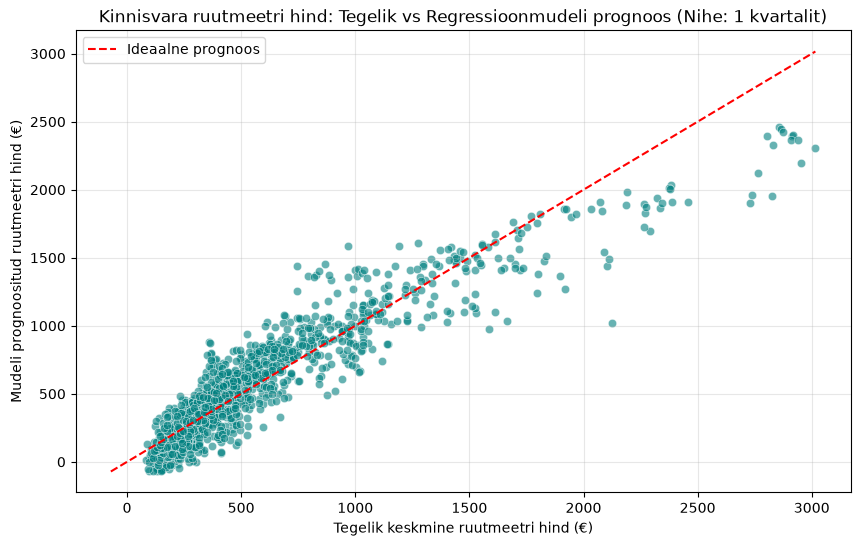


--- PARIMA MUDELI DETAILNE RAPORT ---
                               OLS Regression Results                               
Dep. Variable:     keskmine_ruutmeetri_hind   R-squared:                       0.866
Model:                                  OLS   Adj. R-squared:                  0.864
Method:                       Least Squares   F-statistic:                     463.7
Date:                      Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                              15:33:13   Log-Likelihood:                -8252.1
No. Observations:                      1242   AIC:                         1.654e+04
Df Residuals:                          1224   BIC:                         1.663e+04
Df Model:                                17                                         
Covariance Type:                  nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------

In [76]:
# 3. Visualiseerimine: Tegelik vs Prognoositud hind parima nihke korral
df_parim = parim_tulemus['Andmed'].copy()
parim_mudel = parim_tulemus['Mudel']

# Arvutame mudeli prognoosid
df_parim['prognoositud_hind'] = parim_mudel.predict(sm.add_constant(df_parim[parim_mudel.model.exog_names[1:]]))

# Joonistame graafiku
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_parim, x='keskmine_ruutmeetri_hind', y='prognoositud_hind', alpha=0.6, color='teal')

# Lisame ideaalse prognoosi joone (kus prognoos = tegelik)
max_val = max(df_parim['keskmine_ruutmeetri_hind'].max(), df_parim['prognoositud_hind'].max())
min_val = min(df_parim['keskmine_ruutmeetri_hind'].min(), df_parim['prognoositud_hind'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideaalne prognoos')

plt.title(f'Kinnisvara ruutmeetri hind: Tegelik vs Regressioonmudeli prognoos (Nihe: {parim_nihe} kvartalit)', fontsize=12)
plt.xlabel('Tegelik keskmine ruutmeetri hind (€)', fontsize=10)
plt.ylabel('Mudeli prognoositud ruutmeetri hind (€)', fontsize=10)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Kuvame parima mudeli detailse raporti (p-väärtused ja koefitsiendid)
print("\n--- PARIMA MUDELI DETAILNE RAPORT ---")
print(parim_mudel.summary())

In [77]:
# 3. Visualiseerimine: Tegelik vs Prognoositud hind maakondade lõikes
df_parim = parim_tulemus['Andmed'].copy()
parim_mudel = parim_tulemus['Mudel']

# Arvutame mudeli prognoosid uuesti puhta tabeli põhjal
# Võtame täpsed tunnused, mida mudel ootab (sh dummyd)
X_tunnused = sm.add_constant(df_parim[parim_mudel.model.exog_names[1:]])
df_parim['prognoositud_hind'] = parim_mudel.predict(X_tunnused)

# Joonistame suurema ja selgema graafiku
plt.figure(figsize=(12, 8))

# Kasutame seaborni 'hue' parameetrit, et värvida punktid algse 'maakond' veeru järgi
# 'palette' määrab värviskeemi (juurde on toodud 15 eri värvi Eesti maakondade jaoks)
sns.scatterplot(
    data=df_parim, 
    x='keskmine_ruutmeetri_hind', 
    y='prognoositud_hind', 
    hue='maakond', 
    palette='tab20', 
    alpha=0.8, 
    edgecolor='w', 
    s=50
)

# Lisame ideaalse prognoosi joone (kus prognoos = tegelik)
max_val = max(df_parim['keskmine_ruutmeetri_hind'].max(), df_parim['prognoositud_hind'].max())
min_val = min(df_parim['keskmine_ruutmeetri_hind'].min(), df_parim['prognoositud_hind'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideaalne prognoos')

# Pealkirjad ja kujundus
plt.title(f'Kinnisvara ruutmeetri hind maakonniti: Tegelik vs Regressioonmudel\n(Parim nihe: {parim_nihe} kvartal)', fontsize=14, pad=15)
plt.xlabel('Tegelik keskmine ruutmeetri hind (€)', fontsize=11)
plt.ylabel('Mudeli prognoositud ruutmeetri hind (€)', fontsize=11)

# Paigutame legendi graafikust paremale poole, et see andmeid ära ei varjaks
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Maakonnad & Viited', frameon=True)

plt.grid(True, alpha=0.25, linestyle=':')
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `maakond` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1200x800 with 0 Axes>